# Exploratory Data Analysis (EDA)

# Bharat Bazaar Intelligence Platform

## Introduction

Exploratory Data Analysis (EDA) is a critical phase in the data analytics lifecycle where raw business data is transformed into meaningful insights through statistical analysis and visualization.

This notebook explores the cleaned Global E-Commerce Sales dataset to identify sales trends, profitability drivers, customer purchasing behavior, regional performance, pricing patterns, and operational efficiency.

The objective is not only to understand the dataset but also to generate actionable business insights that support strategic decision-making and improve organizational performance.

This notebook follows industry-standard data analysis practices commonly used by Business Analysts and Data Analysts.

# Business Objectives

The primary objectives of this Exploratory Data Analysis are:

- Understand the overall structure of the dataset.
- Analyze numerical and categorical variables.
- Discover hidden trends and business patterns.
- Identify relationships between important business metrics.
- Detect anomalies and outliers.
- Evaluate sales, profit, discount, and shipping behavior.
- Generate business recommendations based on analytical findings.
- Build a strong analytical foundation for dashboard development and predictive modeling.

# Methodology

The exploratory analysis will be conducted using the following workflow:

1. Data Overview
2. Data Quality Verification
3. Descriptive Statistics
4. Univariate Analysis
5. Categorical Analysis
6. Bivariate Analysis
7. Multivariate Analysis
8. Correlation Analysis
9. Outlier Detection
10. Time Series Analysis
11. Business Insights
12. Strategic Recommendations

Each analytical section includes visualizations, observations, business interpretation, and recommendations.

In [522]:
# ===============================
# Import Required Libraries
# ===============================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Display Options
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Plot Settings
plt.style.use("default")
sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Load Cleaned Dataset

The cleaned dataset produced during the Data Cleaning phase is loaded into the notebook for detailed exploratory analysis.

This dataset has already undergone missing value treatment, duplicate removal, data type validation, and business rule verification.

In [523]:
df = pd.read_csv("../data/cleaned/cleaned_global_ecommerce_sales.csv")

df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


In [524]:
print("=" * 60)
print("DATASET DIMENSIONS")
print("=" * 60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

DATASET DIMENSIONS
Rows    : 2000
Columns : 15


# Dataset Overview

Before performing statistical analysis, it is essential to understand the structure of the dataset.

The following section examines:

- Dataset dimensions
- Feature names
- Data types
- Memory usage
- Overall completeness

This provides a strong foundation for the subsequent exploratory analysis.

# Dataset Information

This section provides a high-level overview of the dataset, including feature names, data types, non-null values, and memory usage.

Understanding the dataset structure helps identify the nature of each feature before statistical analysis.

In [525]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2000 non-null   str    
 1   Order_Date        2000 non-null   str    
 2   Customer_Name     2000 non-null   str    
 3   Customer_Segment  2000 non-null   str    
 4   Country           2000 non-null   str    
 5   Region            2000 non-null   str    
 6   Product_Category  2000 non-null   str    
 7   Product_Name      2000 non-null   str    
 8   Quantity          2000 non-null   int64  
 9   Unit_Price        2000 non-null   float64
 10  Discount_Percent  2000 non-null   int64  
 11  Total_Sales       2000 non-null   float64
 12  Shipping_Cost     2000 non-null   float64
 13  Profit            2000 non-null   float64
 14  Payment_Method    2000 non-null   str    
dtypes: float64(4), int64(2), str(9)
memory usage: 440.1 KB


# Data Dictionary

The dataset contains the following business attributes:

| Feature | Description |
|---------|-------------|
| Order_ID | Unique identifier for each order |
| Order_Date | Date on which the order was placed |
| Customer_Name | Customer who placed the order |
| Customer_Segment | Business classification of the customer |
| Country | Customer's country |
| Region | Geographical region |
| Product_Category | Category of the purchased product |
| Product_Name | Name of the product |
| Quantity | Number of units sold |
| Unit_Price | Price per unit |
| Discount_Percent | Discount applied (%) |
| Total_Sales | Total revenue generated |
| Shipping_Cost | Shipping expense |
| Profit | Profit earned from the transaction |
| Payment_Method | Mode of payment used |

# Data Quality Verification

Before starting exploratory analysis, it is important to verify that the cleaned dataset maintains high data quality.

The following checks confirm:

- Missing values
- Duplicate records
- Data consistency
- Overall dataset readiness

In [526]:
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

df.isnull().sum()

MISSING VALUES


Order_ID            0
Order_Date          0
Customer_Name       0
Customer_Segment    0
Country             0
Region              0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Discount_Percent    0
Total_Sales         0
Shipping_Cost       0
Profit              0
Payment_Method      0
dtype: int64

In [527]:
print("=" * 60)
print("DUPLICATE RECORDS")
print("=" * 60)

print(df.duplicated().sum())

DUPLICATE RECORDS
0


In [528]:
print("=" * 60)
print("DATA TYPES")
print("=" * 60)

df.dtypes

DATA TYPES


Order_ID                str
Order_Date              str
Customer_Name           str
Customer_Segment        str
Country                 str
Region                  str
Product_Category        str
Product_Name            str
Quantity              int64
Unit_Price          float64
Discount_Percent      int64
Total_Sales         float64
Shipping_Cost       float64
Profit              float64
Payment_Method          str
dtype: object

# Data Quality Observation

The cleaned dataset is verified for analytical readiness.

Key observations:

- Missing values have been handled during the data cleaning phase.
- Duplicate records have been removed.
- Data types are consistent with business requirements.
- The dataset is suitable for exploratory data analysis and visualization.

# Descriptive Statistics

Descriptive statistics provide a numerical summary of the dataset and help understand the central tendency, variability, distribution, and overall characteristics of numerical features.

This analysis includes advanced statistical measures commonly used in professional data analytics.

In [529]:
numeric_columns = df.select_dtypes(include=["number"]).columns

numeric_columns

Index(['Quantity', 'Unit_Price', 'Discount_Percent', 'Total_Sales',
       'Shipping_Cost', 'Profit'],
      dtype='str')

In [530]:
stats_summary = pd.DataFrame({
    "Count": df[numeric_columns].count(),
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Std Dev": df[numeric_columns].std(),
    "Variance": df[numeric_columns].var(),
    "Minimum": df[numeric_columns].min(),
    "Maximum": df[numeric_columns].max(),
    "Range": df[numeric_columns].max() - df[numeric_columns].min(),
    "Skewness": df[numeric_columns].skew(),
    "Kurtosis": df[numeric_columns].kurt(),
    "Missing %": (df[numeric_columns].isnull().sum()/len(df))*100,
    "Unique Values": df[numeric_columns].nunique()
})

stats_summary = stats_summary.round(2)

stats_summary

,Count,Mean,Median,Mode,Std Dev,Variance,Minimum,Maximum,Range,Skewness,Kurtosis,Missing %,Unique Values
Quantity,2000,3.56,3.00,1.00,2.70,7.31,1.00,15.00,14.00,1.45,2.02,0.00,15
Unit_Price,2000,73.33,46.42,24.66,79.31,6290.24,3.03,472.56,469.53,2.02,4.41,0.00,1839
Discount_Percent,2000,8.57,10.00,0.00,7.26,52.73,0.00,30.00,30.00,0.62,-0.32,0.00,7
Total_Sales,2000,242.28,113.12,7.02,382.58,146370.37,2.42,3813.98,3811.56,3.90,20.67,0.00,1927
Shipping_Cost,2000,12.90,11.84,9.35,5.22,27.28,5.52,40.44,34.92,1.64,4.02,0.00,1118
Profit,2000,79.44,32.83,-0.55,137.57,18926.49,-11.28,1373.63,1384.91,3.92,21.45,0.00,1855


# Statistical Interpretation Guide

The statistical summary provides valuable insights into the numerical characteristics of the dataset.

The following metrics are particularly important:

- **Mean vs Median** → Detects skewness in the data.
- **Standard Deviation** → Measures variability.
- **Range** → Indicates the spread of values.
- **Skewness** → Identifies asymmetry in distributions.
- **Kurtosis** → Detects the presence of heavy tails or outliers.
- **Missing Percentage** → Confirms data completeness.

In [531]:
stats_summary.sort_values(by="Std Dev", ascending=False)

,Count,Mean,Median,Mode,Std Dev,Variance,Minimum,Maximum,Range,Skewness,Kurtosis,Missing %,Unique Values
Total_Sales,2000,242.28,113.12,7.02,382.58,146370.37,2.42,3813.98,3811.56,3.90,20.67,0.00,1927
Profit,2000,79.44,32.83,-0.55,137.57,18926.49,-11.28,1373.63,1384.91,3.92,21.45,0.00,1855
Unit_Price,2000,73.33,46.42,24.66,79.31,6290.24,3.03,472.56,469.53,2.02,4.41,0.00,1839
Discount_Percent,2000,8.57,10.00,0.00,7.26,52.73,0.00,30.00,30.00,0.62,-0.32,0.00,7
Shipping_Cost,2000,12.90,11.84,9.35,5.22,27.28,5.52,40.44,34.92,1.64,4.02,0.00,1118
Quantity,2000,3.56,3.00,1.00,2.70,7.31,1.00,15.00,14.00,1.45,2.02,0.00,15


# Business Observation

Review the statistical summary to identify:

- Features with the highest variability.
- Variables that exhibit strong positive or negative skewness.
- Columns with wide value ranges.
- Potential indicators of outliers.

These observations guide the selection of appropriate visualization techniques and highlight areas requiring deeper investigation.

# Business Insight

The descriptive statistics establish a quantitative foundation for the exploratory analysis.

Understanding the distribution and variability of numerical variables enables the business to identify operational patterns, evaluate performance consistency, and detect unusual behavior that may influence strategic decision-making.

# Recommendation

The next phase of analysis should focus on visual exploration of numerical variables to validate statistical findings.

Distribution plots, box plots, and relationship analyses will help confirm patterns, identify anomalies, and uncover business opportunities that are not immediately visible from summary statistics alone.

# Univariate Analysis

Univariate analysis examines each numerical feature individually to understand its distribution, central tendency, variability, and potential outliers.

This analysis provides valuable insights into customer purchasing behavior, sales performance, pricing strategy, profitability, and logistics.

# Analysis 1 — Total Sales Distribution

The Total Sales feature represents the revenue generated from each transaction.

Understanding its distribution helps identify customer spending behavior, revenue concentration, and unusually high-value transactions.

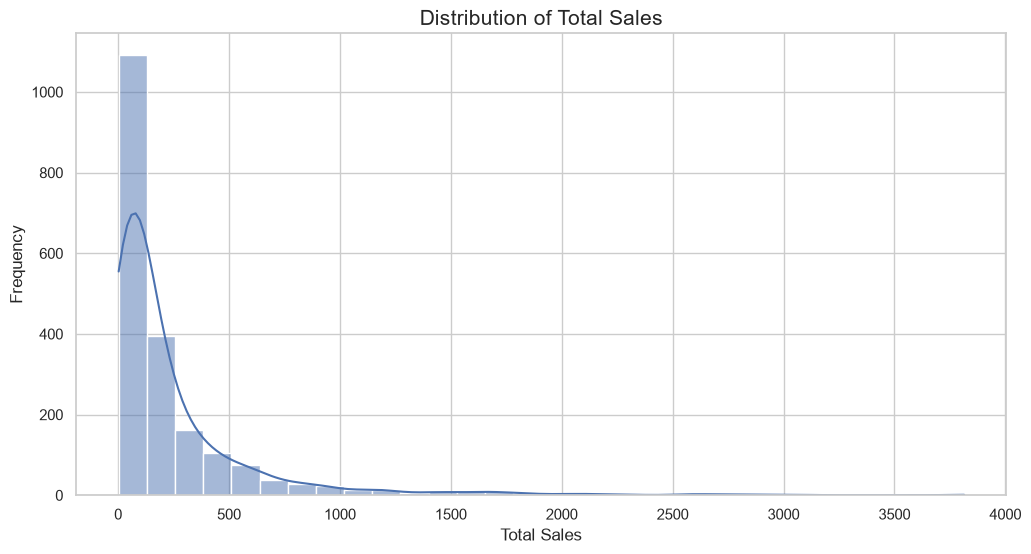

In [532]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="Total_Sales",
    bins=30,
    kde=True
)

plt.title("Distribution of Total Sales", fontsize=15)
plt.xlabel("Total Sales")
plt.ylabel("Frequency")

plt.show()

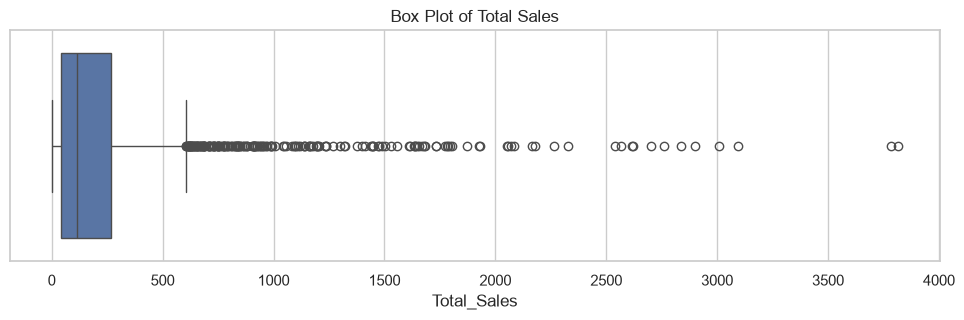

In [533]:
plt.figure(figsize=(12,3))

sns.boxplot(
    x=df["Total_Sales"]
)

plt.title("Box Plot of Total Sales")

plt.show()

# Statistical Observation

Review the histogram and box plot to determine:

- Shape of the distribution
- Presence of skewness
- Frequency concentration
- Extreme values (outliers)

These observations provide statistical evidence regarding customer spending behavior.

# Business Insight

The distribution of Total Sales reveals how customer purchases contribute to overall business revenue.

If the distribution is positively skewed, it indicates that a relatively small number of high-value orders contribute significantly to total sales. Understanding this pattern helps prioritize high-value customers and optimize sales strategies.

# Business Recommendation

Identify high-value customers responsible for premium purchases and design personalized marketing campaigns, loyalty programs, and cross-selling opportunities to maximize customer lifetime value.

# Potential Business Risk

Heavy dependence on a small number of high-value transactions may expose the business to revenue instability if these customers reduce their purchasing activity.

Monitoring customer concentration and diversifying revenue sources can help reduce business risk.

# Analysis 2 — Profit Distribution

Profit is one of the most important business performance indicators.

Analyzing the distribution of profit helps identify whether most transactions generate healthy returns or whether profitability is concentrated in a limited number of orders.

This analysis also helps detect unusually high-profit or low-profit transactions.

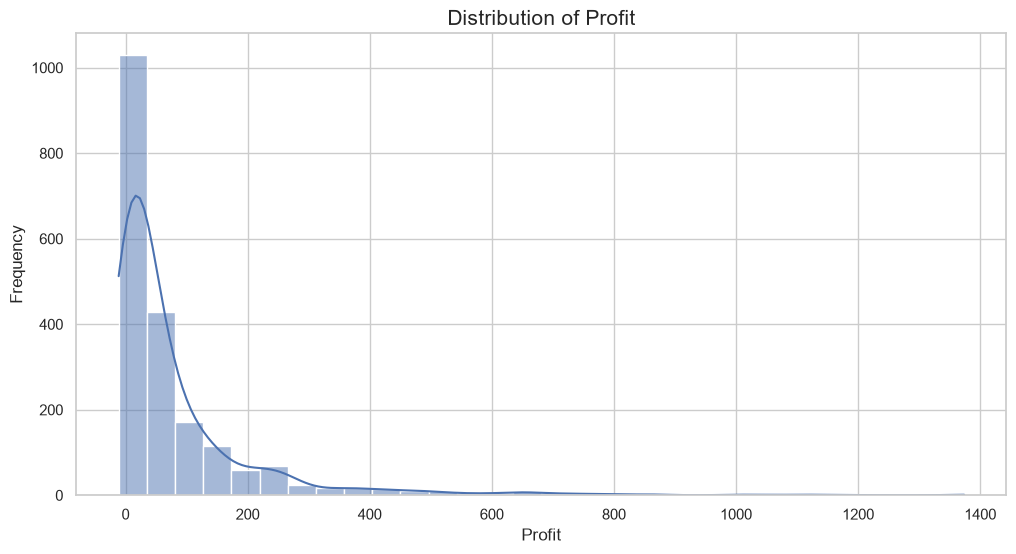

In [534]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="Profit",
    bins=30,
    kde=True
)

plt.title("Distribution of Profit", fontsize=15)
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

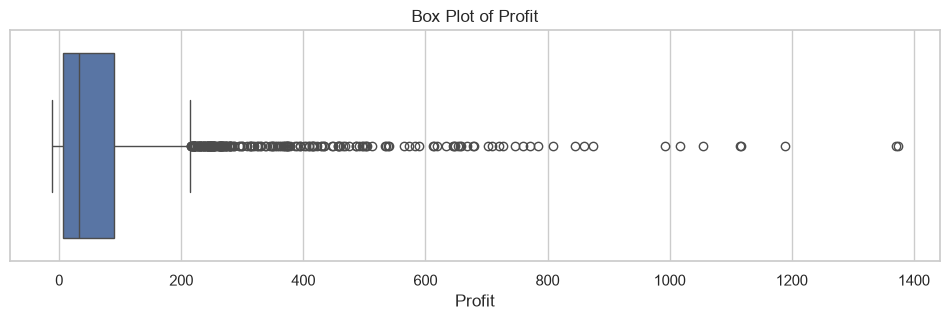

In [535]:
plt.figure(figsize=(12,3))

sns.boxplot(
    x=df["Profit"]
)

plt.title("Box Plot of Profit")

plt.show()

In [536]:
profit_summary = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Maximum",
        "Skewness",
        "Kurtosis"
    ],
    "Value": [
        df["Profit"].mean(),
        df["Profit"].median(),
        df["Profit"].std(),
        df["Profit"].min(),
        df["Profit"].max(),
        df["Profit"].skew(),
        df["Profit"].kurt()
    ]
})

profit_summary["Value"] = profit_summary["Value"].round(2)

profit_summary

,Statistic,Value
0,Mean,79.44
1,Median,32.83
2,Standard Deviation,137.57
3,Minimum,-11.28
4,Maximum,1373.63
5,Skewness,3.92
6,Kurtosis,21.45


# Key Findings

Review the visualizations and statistical summary to identify:

- Distribution pattern of profit.
- Presence of skewness.
- Extreme profit values.
- Potential outliers.
- Overall variability in profitability.

# Business Interpretation

Profit distribution provides insight into the financial health of the business.

If profit values are concentrated within a narrow range, business performance is relatively stable. Conversely, highly variable profit values may indicate inconsistent pricing, promotional strategies, or product performance.

# Potential Business Risk

Large variations in profit may expose the business to financial uncertainty.

Regular profitability monitoring and margin optimization strategies should be implemented to maintain sustainable business growth.

# Next Analytical Question

While the current analysis explains the distribution of profit, it does not explain *why* certain transactions are more profitable.

The next analysis investigates the distribution of Quantity sold to determine whether order size influences profitability.

# Analysis 3 — Quantity Distribution

Quantity represents the number of units purchased in each transaction.

Understanding the distribution of quantity helps identify customer purchasing behavior, common order sizes, and inventory demand patterns. It also provides valuable insights for stock planning and demand forecasting.

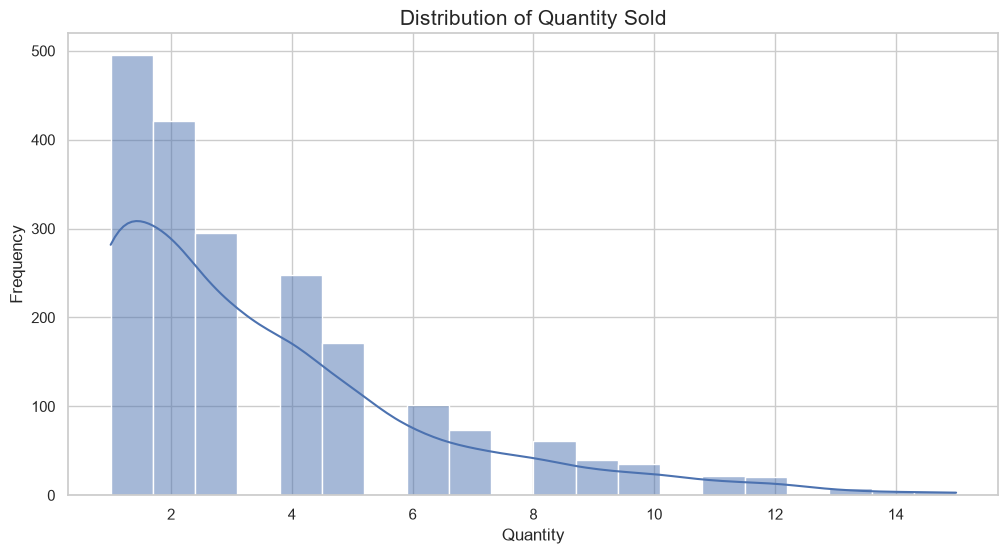

In [537]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="Quantity",
    bins=20,
    kde=True
)

plt.title("Distribution of Quantity Sold", fontsize=15)
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

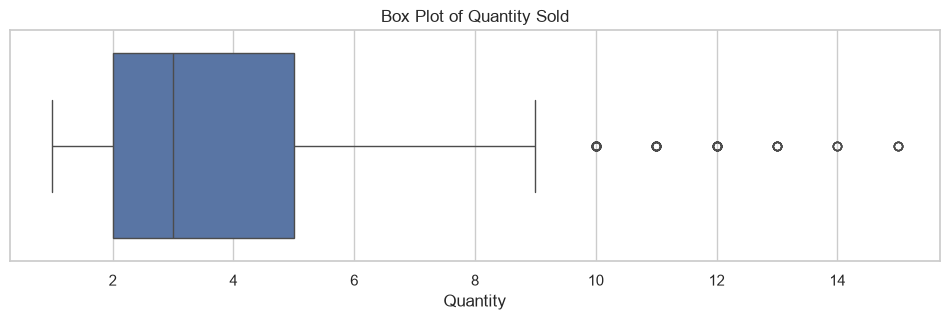

In [538]:
plt.figure(figsize=(12,3))

sns.boxplot(
    x=df["Quantity"]
)

plt.title("Box Plot of Quantity Sold")

plt.show()

In [539]:
quantity_summary = pd.DataFrame({
    "Statistic":[
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Maximum",
        "Skewness",
        "Kurtosis"
    ],
    "Value":[
        df["Quantity"].mean(),
        df["Quantity"].median(),
        df["Quantity"].std(),
        df["Quantity"].min(),
        df["Quantity"].max(),
        df["Quantity"].skew(),
        df["Quantity"].kurt()
    ]
})

quantity_summary["Value"] = quantity_summary["Value"].round(2)

quantity_summary

,Statistic,Value
0,Mean,3.56
1,Median,3.00
2,Standard Deviation,2.70
3,Minimum,1.00
4,Maximum,15.00
5,Skewness,1.45
6,Kurtosis,2.02


# Key Findings

Analyze the results to determine:

- Most common order quantity.
- Presence of unusually large orders.
- Distribution symmetry.
- Quantity variability across transactions.

# Business Interpretation

The quantity distribution provides insights into customer purchasing patterns. If most transactions involve small quantities, the business may rely on frequent purchases. Large order quantities may represent wholesale customers or bulk purchasing behavior.

# Strategic Recommendation

Optimize inventory management based on the most frequently ordered quantities. Consider targeted pricing or bulk purchase incentives for customers placing larger orders to increase overall sales volume.

# Potential Business Risk

Unexpected spikes in order quantities may create inventory shortages if demand forecasting is inaccurate. Regular monitoring of purchasing patterns can reduce stock-out risks and improve supply chain efficiency.

# Next Analytical Question

Does the selling price of products influence customer purchasing behavior?

The next analysis examines the distribution of Unit Price to understand pricing patterns and identify premium and budget product segments.

# Analysis 4 — Unit Price Distribution

## Business Question

How are products priced across different transactions?

Understanding the distribution of unit prices helps identify pricing strategies, premium product segments, and budget-friendly offerings. This analysis also highlights pricing consistency and potential pricing anomalies.

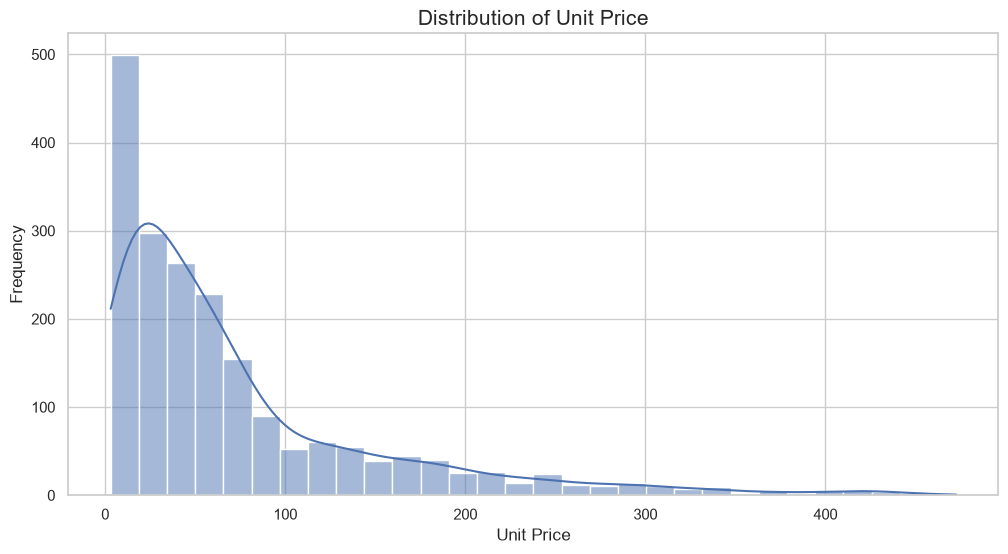

In [540]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="Unit_Price",
    bins=30,
    kde=True
)

plt.title("Distribution of Unit Price", fontsize=15)
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()

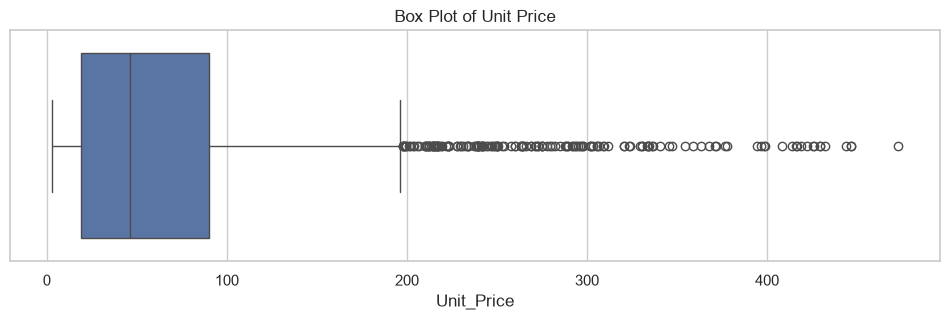

In [541]:

plt.figure(figsize=(12, 3))

sns.boxplot(
    x=df["Unit_Price"]
)

plt.title("Box Plot of Unit Price")

plt.show()

In [542]:
unit_price_summary = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Maximum",
        "Skewness",
        "Kurtosis"
    ],
    "Value": [
        df["Unit_Price"].mean(),
        df["Unit_Price"].median(),
        df["Unit_Price"].std(),
        df["Unit_Price"].min(),
        df["Unit_Price"].max(),
        df["Unit_Price"].skew(),
        df["Unit_Price"].kurt()
    ]
})

unit_price_summary["Value"] = unit_price_summary["Value"].round(2)

unit_price_summary

,Statistic,Value
0,Mean,73.33
1,Median,46.42
2,Standard Deviation,79.31
3,Minimum,3.03
4,Maximum,472.56
5,Skewness,2.02
6,Kurtosis,4.41


# Key Findings

Analyze the results to determine:

- Is the pricing distribution balanced or skewed?
- Are premium-priced products limited to a few transactions?
- Are there any unusually high-priced products?

# Business Interpretation

The unit price distribution reflects the company's pricing strategy. A balanced distribution indicates a diversified product portfolio, while a highly skewed distribution may suggest dependence on either low-cost or premium products.

# Strategic Recommendation

Review pricing across product categories to ensure competitiveness while maintaining healthy profit margins. Premium products should be supported with targeted marketing, whereas budget products should focus on driving higher sales volume.

# Potential Business Risk

Over-reliance on either premium-priced or low-priced products may increase business risk. A balanced pricing strategy helps improve market resilience and customer reach.

# Analysis 5 — Discount Distribution

## Business Question

How are discounts distributed across customer transactions, and do they indicate an aggressive or balanced pricing strategy?

Discount analysis helps evaluate promotional strategies, pricing consistency, and the potential impact of discounts on business profitability.

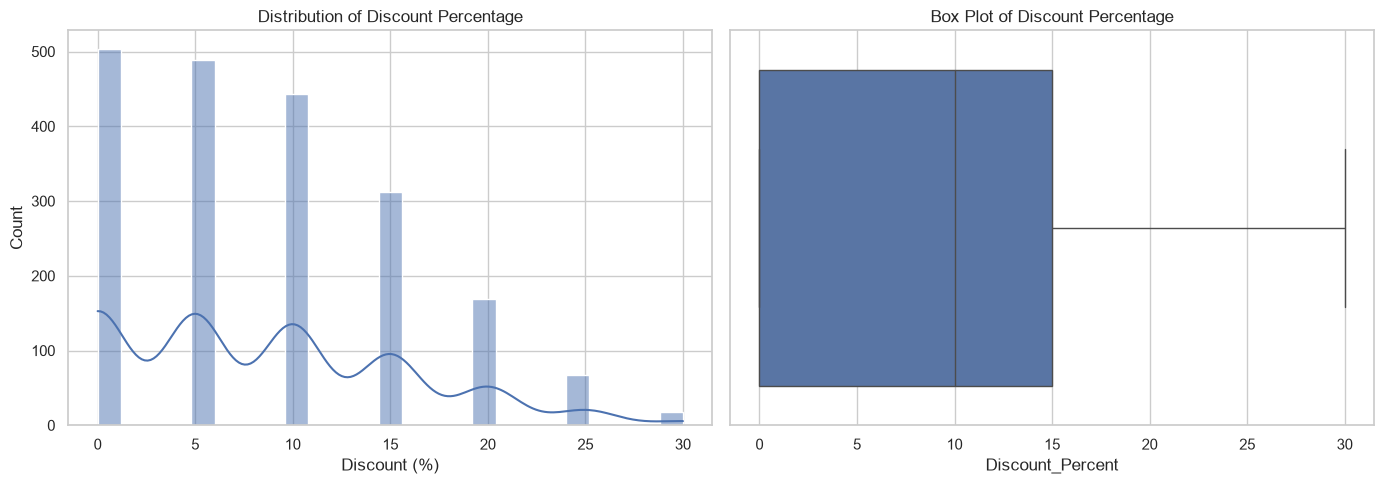

In [543]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(
    data=df,
    x="Discount_Percent",
    bins=25,
    kde=True,
    ax=ax[0]
)

ax[0].set_title("Distribution of Discount Percentage")
ax[0].set_xlabel("Discount (%)")

# Box Plot
sns.boxplot(
    x=df["Discount_Percent"],
    ax=ax[1]
)

ax[1].set_title("Box Plot of Discount Percentage")

plt.tight_layout()
plt.show()

In [544]:
discount_summary = pd.DataFrame({
    "Metric": [
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Maximum",
        "Skewness",
        "Kurtosis"
    ],
    "Value": [
        df["Discount_Percent"].mean(),
        df["Discount_Percent"].median(),
        df["Discount_Percent"].std(),
        df["Discount_Percent"].min(),
        df["Discount_Percent"].max(),
        df["Discount_Percent"].skew(),
        df["Discount_Percent"].kurt()
    ]
})

discount_summary["Value"] = discount_summary["Value"].round(2)

discount_summary

,Metric,Value
0,Mean,8.57
1,Median,10.00
2,Standard Deviation,7.26
3,Minimum,0.00
4,Maximum,30.00
5,Skewness,0.62
6,Kurtosis,-0.32


# Business Findings

### Key Observations
- Review the shape of the discount distribution.
- Identify whether discounts are concentrated within a specific range.
- Check for unusually high discount values.

### Business Interpretation
The distribution reflects the organization's pricing and promotional strategy. Consistently high discounts may increase sales volume but can negatively affect profit margins if not managed carefully.

### Recommendation
Evaluate the effectiveness of discount campaigns by comparing discount levels with sales growth and profitability. Focus on data-driven promotional strategies rather than uniform discounting.

# Analysis 6 — Shipping Cost Distribution

## Business Question

How are shipping costs distributed across customer orders?

Shipping cost is a key operational expense that directly impacts business profitability. Analyzing its distribution helps identify logistics patterns, unusual shipping expenses, and opportunities for cost optimization.

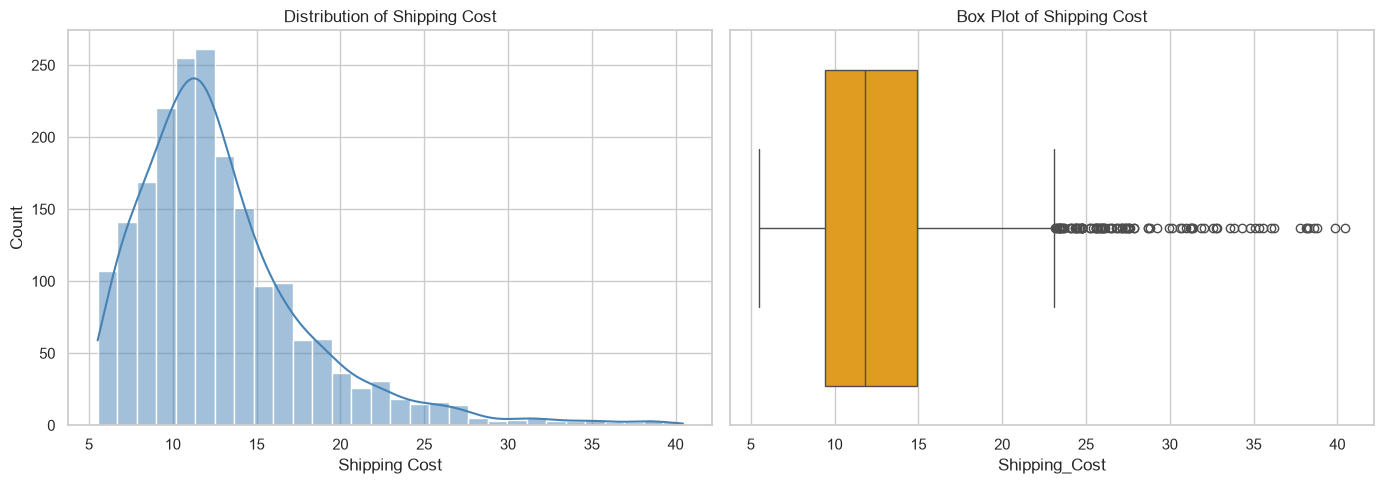

In [545]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(
    data=df,
    x="Shipping_Cost",
    bins=30,
    kde=True,
    ax=ax[0],
    color="steelblue"
)

ax[0].set_title("Distribution of Shipping Cost")
ax[0].set_xlabel("Shipping Cost")

# Box Plot
sns.boxplot(
    x=df["Shipping_Cost"],
    ax=ax[1],
    color="orange"
)

ax[1].set_title("Box Plot of Shipping Cost")

plt.tight_layout()
plt.show()

In [546]:
shipping_summary = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Maximum",
        "Skewness",
        "Kurtosis"
    ],
    "Value": [
        df["Shipping_Cost"].mean(),
        df["Shipping_Cost"].median(),
        df["Shipping_Cost"].std(),
        df["Shipping_Cost"].min(),
        df["Shipping_Cost"].max(),
        df["Shipping_Cost"].skew(),
        df["Shipping_Cost"].kurt()
    ]
})

shipping_summary["Value"] = shipping_summary["Value"].round(2)

shipping_summary

,Statistic,Value
0,Mean,12.90
1,Median,11.84
2,Standard Deviation,5.22
3,Minimum,5.52
4,Maximum,40.44
5,Skewness,1.64
6,Kurtosis,4.02


# Business Findings

### Key Observations
- Examine the distribution of shipping costs.
- Identify any extreme shipping charges.
- Compare the mean and median to assess skewness.

### Business Interpretation
Shipping costs represent a significant operational expense. Understanding their distribution helps identify opportunities to optimize logistics and reduce unnecessary costs.

### Recommendation
Monitor transactions with exceptionally high shipping costs and evaluate logistics partners, warehouse locations, and delivery strategies to improve operational efficiency while maintaining customer satisfaction.

# Categorical Analysis 1 — Product Category Performance

## Business Question

Which product categories generate the highest business value?

Product category analysis helps identify the categories that contribute the most to revenue. These insights support inventory planning, marketing investment, and strategic product portfolio decisions.

In [547]:
category_sales = (
    df.groupby("Product_Category", as_index=False)
      .agg(
          Total_Sales=("Total_Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "count")
      )
      .sort_values("Total_Sales", ascending=False)
)

category_sales

,Product_Category,Total_Sales,Total_Profit,Total_Orders
1,Furniture,256274.68,81171.57,507
3,Technology,139518.22,48268.65,567
0,Clothing & Accessories,69375.63,26112.94,413
2,Office Supplies,19390.81,3319.16,513


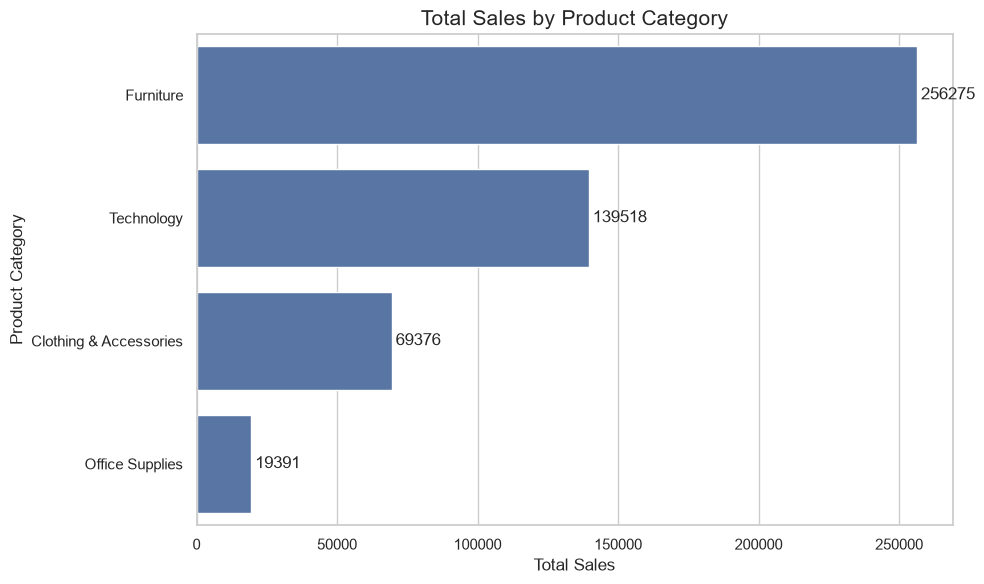

In [548]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=category_sales,
    x="Total_Sales",
    y="Product_Category"
)

plt.title("Total Sales by Product Category", fontsize=15)
plt.xlabel("Total Sales")
plt.ylabel("Product Category")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [549]:
category_sales.style.format({
    "Total_Sales": "{:,.2f}",
    "Total_Profit": "{:,.2f}"
})

,Product_Category,Total_Sales,Total_Profit,Total_Orders
1,Furniture,"256,274.68","81,171.57",507
3,Technology,"139,518.22","48,268.65",567
0,Clothing & Accessories,"69,375.63","26,112.94",413
2,Office Supplies,"19,390.81","3,319.16",513


# Business Findings

### Key Observations
- Identify the highest-performing product category by total sales.
- Compare sales with total profit to evaluate whether high revenue also results in high profitability.
- Review the number of orders handled by each category.

### Business Interpretation
Categories generating both high sales and high profit should be considered strategic business assets. Categories with strong sales but comparatively lower profit may require pricing or cost optimization.

### Recommendation
Increase investment in high-performing categories through inventory expansion, targeted marketing campaigns, and promotional planning. Review underperforming categories to identify opportunities for product improvement or cost reduction.

In [550]:
category_sales["Sales_Rank"] = (
    category_sales["Total_Sales"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

category_sales[
    ["Sales_Rank",
     "Product_Category",
     "Total_Sales",
     "Total_Profit",
     "Total_Orders"]
]

,Sales_Rank,Product_Category,Total_Sales,Total_Profit,Total_Orders
1,1,Furniture,256274.68,81171.57,507
3,2,Technology,139518.22,48268.65,567
0,3,Clothing & Accessories,69375.63,26112.94,413
2,4,Office Supplies,19390.81,3319.16,513


# Categorical Analysis 2 — Product Category Profitability

## Business Question

Which product categories generate the highest profit?

While revenue indicates business growth, profit reflects financial success. This analysis evaluates product categories based on profitability to identify high-margin business segments and opportunities for strategic investment.

In [551]:
category_profit = (
    df.groupby("Product_Category", as_index=False)
      .agg(
          Total_Sales=("Total_Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
)

category_profit["Profit_Margin (%)"] = (
    category_profit["Total_Profit"] /
    category_profit["Total_Sales"] * 100
).round(2)

category_profit = category_profit.sort_values(
    by="Total_Profit",
    ascending=False
)

category_profit

,Product_Category,Total_Sales,Total_Profit,Profit_Margin (%)
1,Furniture,256274.68,81171.57,31.67
3,Technology,139518.22,48268.65,34.60
0,Clothing & Accessories,69375.63,26112.94,37.64
2,Office Supplies,19390.81,3319.16,17.12


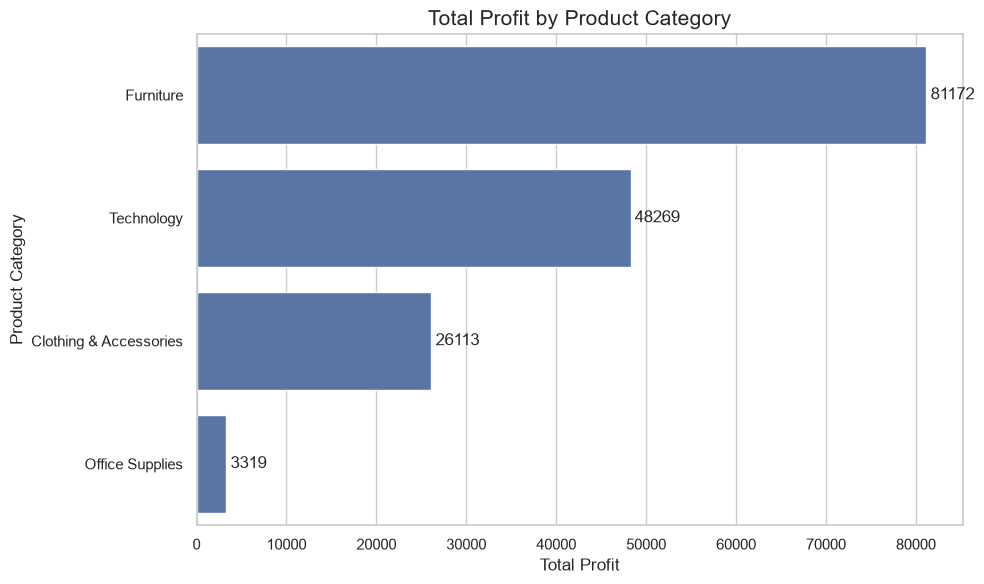

In [552]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=category_profit,
    x="Total_Profit",
    y="Product_Category"
)

plt.title("Total Profit by Product Category", fontsize=15)
plt.xlabel("Total Profit")
plt.ylabel("Product Category")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [553]:
category_profit.style.format({
    "Total_Sales": "{:,.2f}",
    "Total_Profit": "{:,.2f}",
    "Profit_Margin (%)": "{:.2f}%"
})

,Product_Category,Total_Sales,Total_Profit,Profit_Margin (%)
1,Furniture,"256,274.68","81,171.57",31.67%
3,Technology,"139,518.22","48,268.65",34.60%
0,Clothing & Accessories,"69,375.63","26,112.94",37.64%
2,Office Supplies,"19,390.81","3,319.16",17.12%


# Business Findings

### Key Observations

- Identify the product category with the highest total profit.
- Compare revenue with profitability across categories.
- Evaluate whether higher sales translate into higher profit margins.

### Business Interpretation

High-profit categories contribute more effectively to business sustainability than categories generating only high sales. Profit margin analysis helps identify where investments produce the greatest financial return.

### Recommendation

Prioritize high-margin product categories through strategic inventory planning, focused marketing campaigns, and supplier negotiations. Review categories with low profit margins to identify opportunities for pricing improvements and cost optimization.

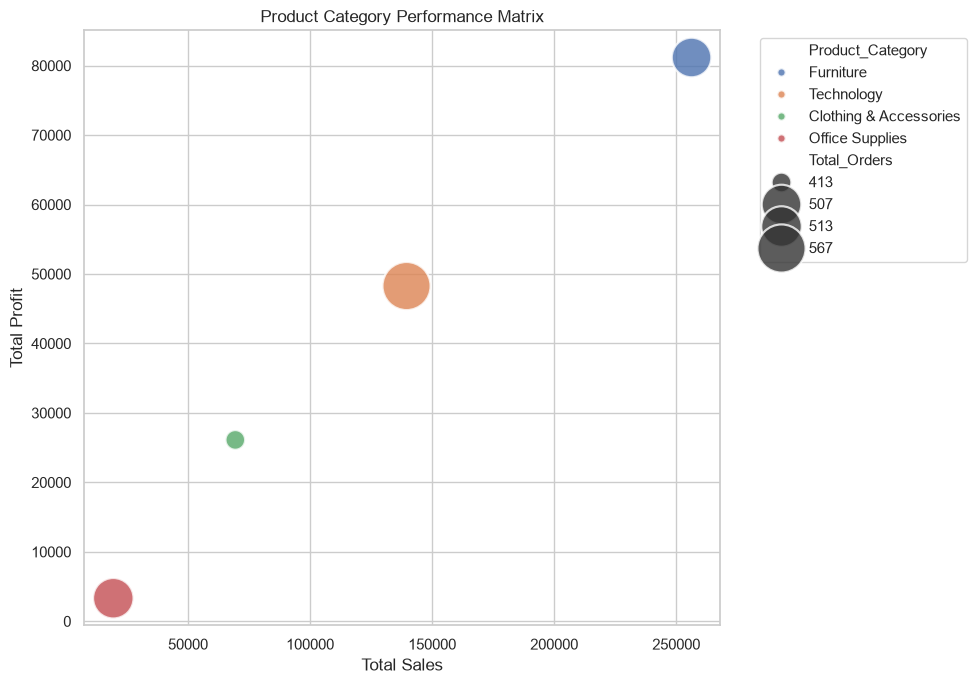

In [554]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=category_sales,
    x="Total_Sales",
    y="Total_Profit",
    size="Total_Orders",
    hue="Product_Category",
    sizes=(200, 1200),
    alpha=0.8
)

plt.title("Product Category Performance Matrix")
plt.xlabel("Total Sales")
plt.ylabel("Total Profit")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Categorical Analysis 3 — Customer Segment Performance

## Business Question

Which customer segment contributes the most to business performance?

Customer segmentation analysis helps identify the most valuable customer groups based on revenue, profitability, and purchasing activity. These insights support targeted marketing, customer retention, and resource allocation strategies.

In [555]:
customer_segment = (
    df.groupby("Customer_Segment", as_index=False)
      .agg(
          Total_Sales=("Total_Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "count"),
          Average_Order_Value=("Total_Sales", "mean")
      )
)

customer_segment = customer_segment.sort_values(
    by="Total_Sales",
    ascending=False
)

customer_segment

,Customer_Segment,Total_Sales,Total_Profit,Total_Orders,Average_Order_Value
0,Consumer,256287.74,87300.36,1006,254.76
1,Corporate,146050.39,44463.44,623,234.43
2,Home Office,82221.21,27108.52,371,221.62


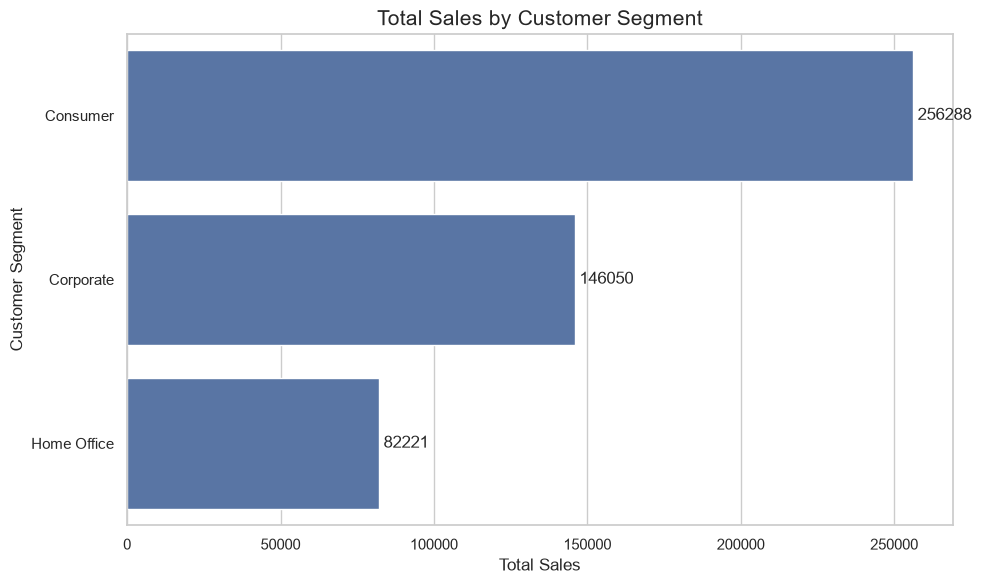

In [556]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=customer_segment,
    x="Total_Sales",
    y="Customer_Segment"
)

plt.title("Total Sales by Customer Segment", fontsize=15)
plt.xlabel("Total Sales")
plt.ylabel("Customer Segment")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [557]:
customer_segment.style.format({
    "Total_Sales": "{:,.2f}",
    "Total_Profit": "{:,.2f}",
    "Average_Order_Value": "{:,.2f}"
})

,Customer_Segment,Total_Sales,Total_Profit,Total_Orders,Average_Order_Value
0,Consumer,"256,287.74","87,300.36",1006,254.76
1,Corporate,"146,050.39","44,463.44",623,234.43
2,Home Office,"82,221.21","27,108.52",371,221.62


# Business Findings

### Key Observations

- Identify the customer segment generating the highest revenue.
- Compare sales with profitability across customer segments.
- Evaluate which segment places the highest number of orders.
- Review the Average Order Value (AOV) for each segment.

### Business Interpretation

Customer segments with high sales, strong profitability, and higher average order values represent the most valuable customers. Understanding these segments enables the business to optimize marketing investments and improve customer lifetime value.

### Recommendation

Develop personalized marketing campaigns, loyalty programs, and premium service offerings for high-value customer segments. Lower-performing segments should be analyzed further to identify opportunities for engagement and revenue growth.

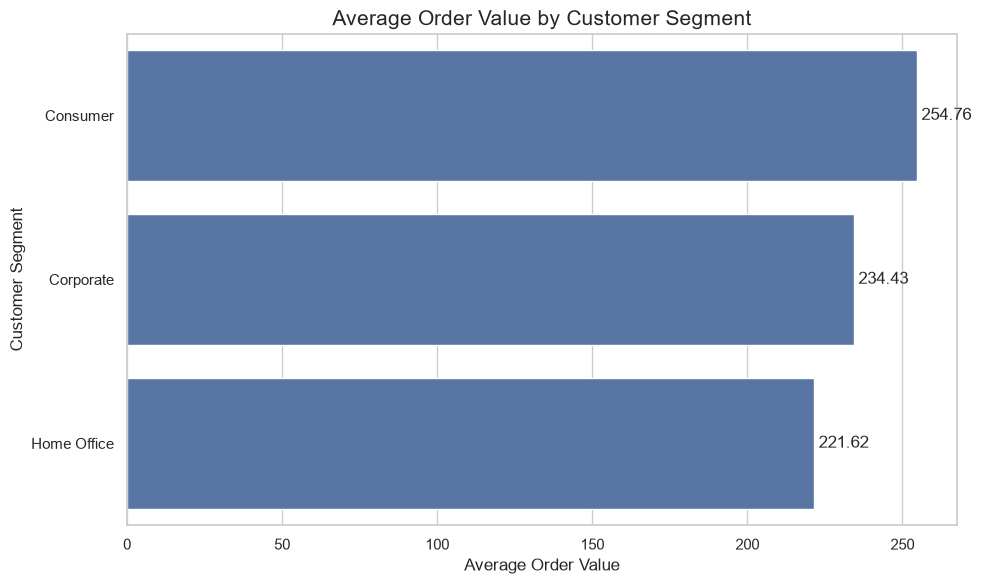

In [558]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=customer_segment,
    x="Average_Order_Value",
    y="Customer_Segment"
)

plt.title("Average Order Value by Customer Segment", fontsize=15)
plt.xlabel("Average Order Value")
plt.ylabel("Customer Segment")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

# Categorical Analysis 4 — Regional Performance Analysis

## Business Question

Which geographical regions contribute the most to business performance?

Regional analysis helps evaluate market performance across different locations. Understanding regional sales and profitability supports strategic expansion, resource allocation, and market-specific business decisions.

In [559]:
region_performance = (
    df.groupby("Region", as_index=False)
      .agg(
          Total_Sales=("Total_Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order_ID", "count"),
          Average_Order_Value=("Total_Sales", "mean")
      )
      .sort_values(by="Total_Sales", ascending=False)
)

region_performance

,Region,Total_Sales,Total_Profit,Total_Orders,Average_Order_Value
1,Europe,137006.20,45672.16,503,272.38
3,North America,133876.38,45250.09,578,231.62
0,Asia Pacific,121707.51,39116.61,520,234.05
4,South America,46051.13,14680.98,191,241.11
2,Middle East & Africa,45918.12,14152.48,208,220.76


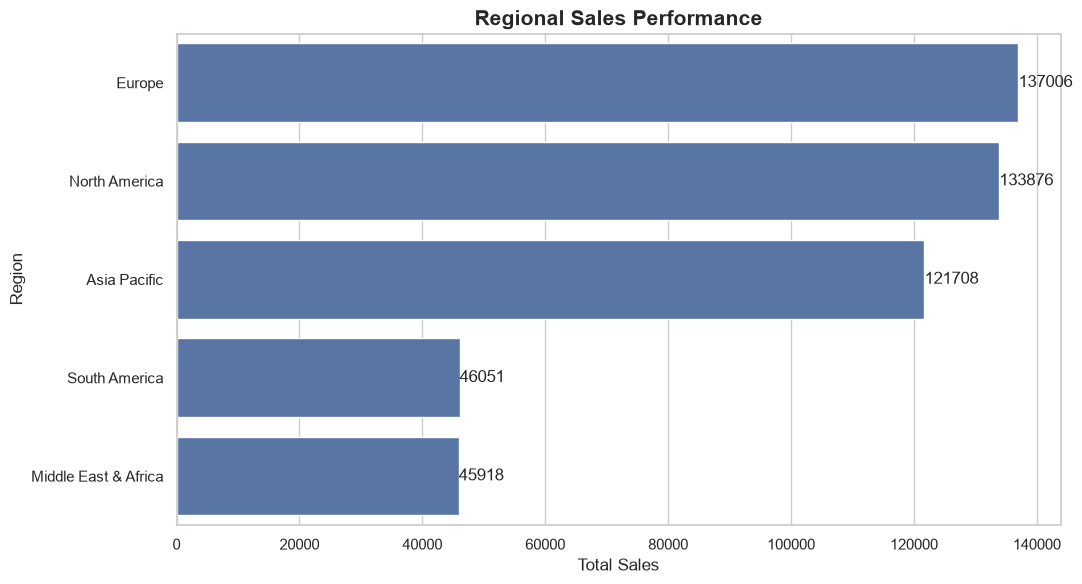

In [560]:
plt.figure(figsize=(11,6))

ax = sns.barplot(
    data=region_performance,
    x="Total_Sales",
    y="Region"
)

plt.title("Regional Sales Performance", fontsize=15, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Region")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

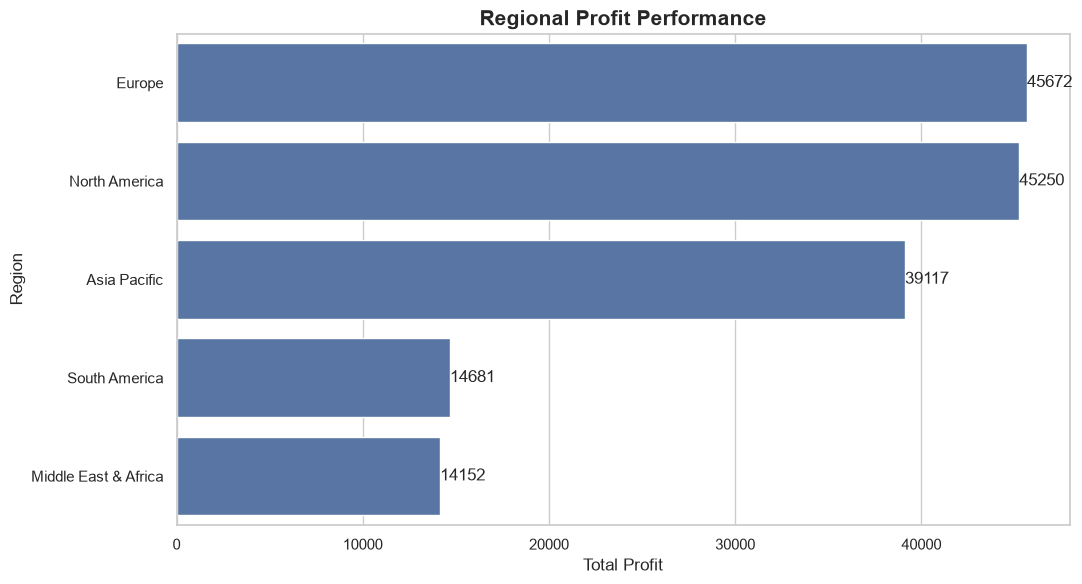

In [561]:
plt.figure(figsize=(11,6))

ax = sns.barplot(
    data=region_performance,
    x="Total_Profit",
    y="Region"
)

plt.title("Regional Profit Performance", fontsize=15, fontweight="bold")
plt.xlabel("Total Profit")
plt.ylabel("Region")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

In [562]:
region_performance.style.format({
    "Total_Sales":"{:,.2f}",
    "Total_Profit":"{:,.2f}",
    "Average_Order_Value":"{:,.2f}"
})

,Region,Total_Sales,Total_Profit,Total_Orders,Average_Order_Value
1,Europe,"137,006.20","45,672.16",503,272.38
3,North America,"133,876.38","45,250.09",578,231.62
0,Asia Pacific,"121,707.51","39,116.61",520,234.05
4,South America,"46,051.13","14,680.98",191,241.11
2,Middle East & Africa,"45,918.12","14,152.48",208,220.76


# Business Findings

### Key Observations

- Identify the highest-performing region based on sales.
- Compare profitability across all regions.
- Analyze whether regions with higher sales also generate higher profits.
- Evaluate regional purchasing behavior using Average Order Value.

### Business Interpretation

Regional performance highlights where the business has established a strong market presence. Regions with consistently high sales and profit indicate mature markets, while lower-performing regions may represent opportunities for expansion or strategic improvement.

### Recommendation

Increase investment and marketing efforts in high-performing regions while conducting detailed market analysis for underperforming regions. Optimize regional operations by identifying successful practices that can be replicated across other markets.

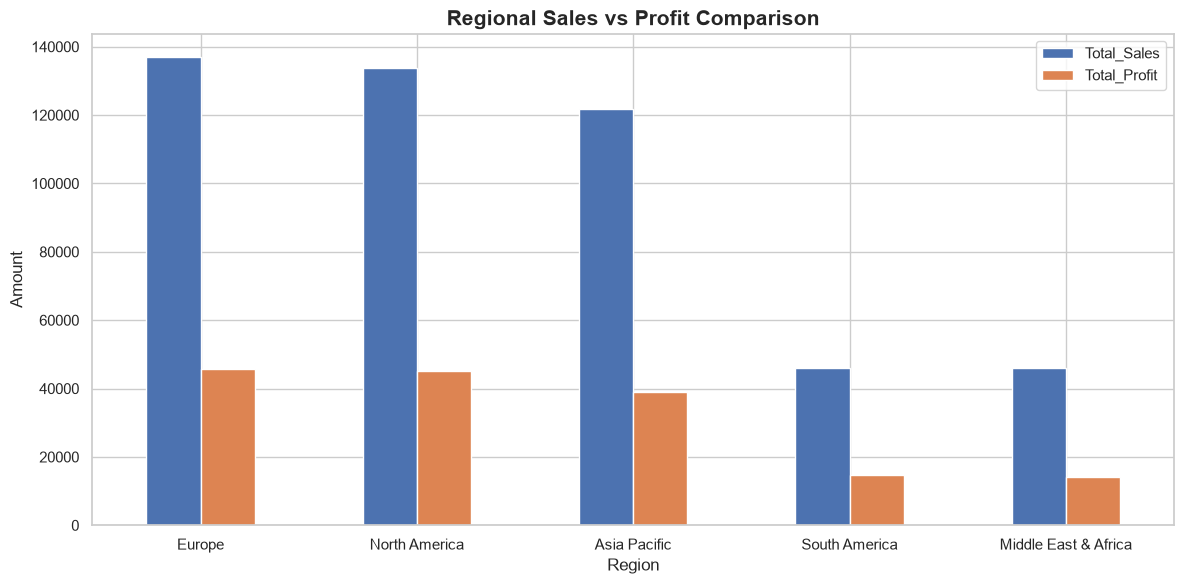

In [563]:
region_compare = region_performance.set_index("Region")[["Total_Sales", "Total_Profit"]]

region_compare.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Regional Sales vs Profit Comparison", fontsize=15, fontweight="bold")
plt.ylabel("Amount")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

# Categorical Analysis 5 — Payment Method Analysis

## Business Question

Which payment methods are most frequently used by customers?

Payment method analysis helps understand customer payment preferences, evaluate transaction behavior, and identify opportunities to improve the payment experience.

In [564]:
payment_summary = (
    df.groupby("Payment_Method", as_index=False)
      .agg(
          Total_Orders=("Order_ID", "count"),
          Total_Sales=("Total_Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
      .sort_values(by="Total_Orders", ascending=False)
)

payment_summary

,Payment_Method,Total_Orders,Total_Sales,Total_Profit
2,Credit Card,797,192717.89,62323.24
3,PayPal,609,143112.87,47288.80
1,Cash on Delivery,301,77129.54,25704.89
0,Bank Transfer,293,71599.04,23555.39


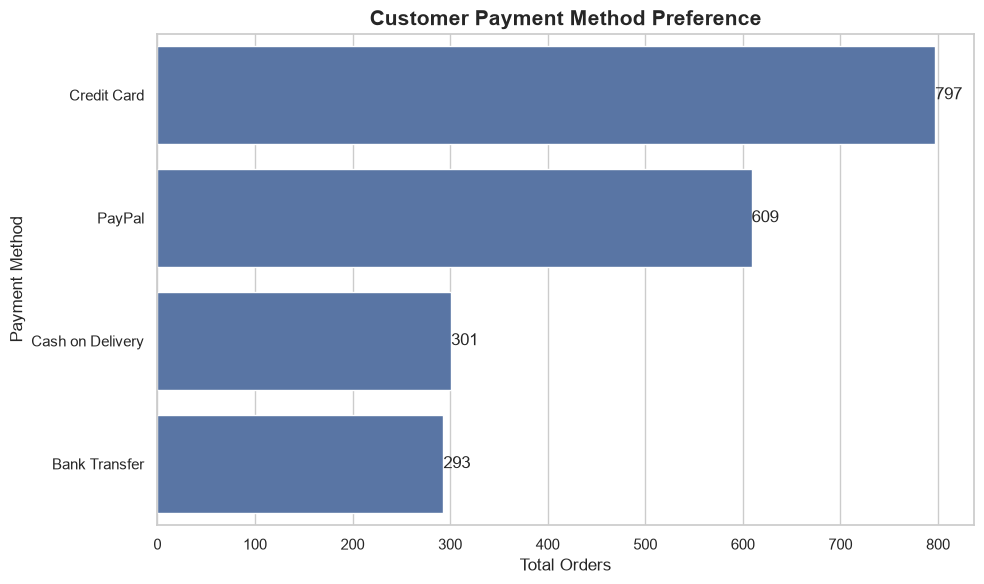

In [565]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=payment_summary,
    x="Total_Orders",
    y="Payment_Method"
)

plt.title("Customer Payment Method Preference", fontsize=15, fontweight="bold")
plt.xlabel("Total Orders")
plt.ylabel("Payment Method")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

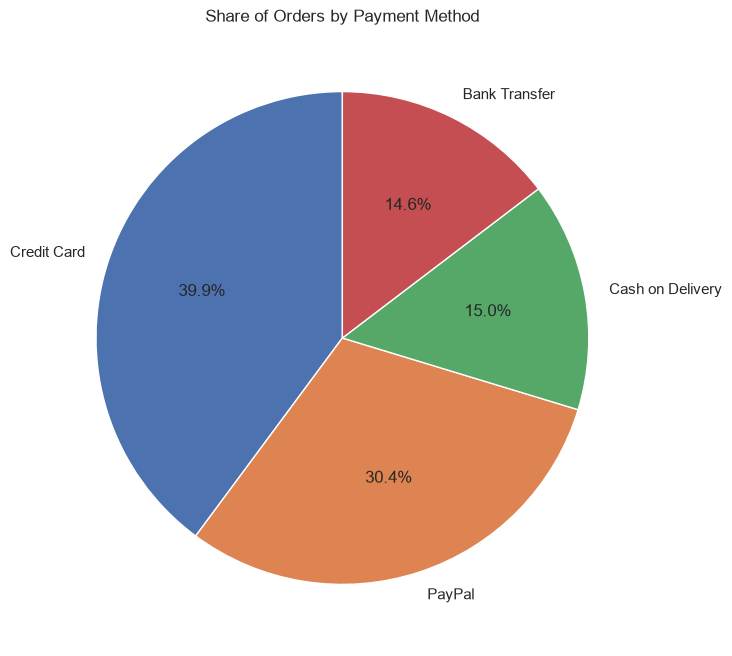

In [566]:
plt.figure(figsize=(8,8))

plt.pie(
    payment_summary["Total_Orders"],
    labels=payment_summary["Payment_Method"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Share of Orders by Payment Method")

plt.show()

In [567]:
payment_summary.style.format({
    "Total_Sales":"{:,.2f}",
    "Total_Profit":"{:,.2f}"
})

,Payment_Method,Total_Orders,Total_Sales,Total_Profit
2,Credit Card,797,"192,717.89","62,323.24"
3,PayPal,609,"143,112.87","47,288.80"
1,Cash on Delivery,301,"77,129.54","25,704.89"
0,Bank Transfer,293,"71,599.04","23,555.39"


# Business Findings

### Key Observations

- Identify the most preferred payment method.
- Compare payment methods by sales contribution.
- Evaluate whether the most frequently used payment method also generates the highest revenue.

### Business Interpretation

Customer payment preferences provide valuable insights into purchasing behavior and transaction convenience. A dominant payment method indicates where the business should focus optimization efforts to improve customer experience.

### Recommendation

Ensure the most frequently used payment methods remain reliable and secure. Promote alternative payment options through incentives to reduce dependence on a single payment channel and enhance customer flexibility.

# Bivariate Analysis 1 — Discount vs Profit

## Business Question

Does offering higher discounts reduce business profitability?

Discounts are commonly used to increase sales, but excessive discounting may negatively impact profit. This analysis evaluates the relationship between discount percentage and profit.

In [568]:
print(df.columns)

Index(['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment',
       'Country', 'Region', 'Product_Category', 'Product_Name', 'Quantity',
       'Unit_Price', 'Discount_Percent', 'Total_Sales', 'Shipping_Cost',
       'Profit', 'Payment_Method'],
      dtype='str')


In [569]:
for col in df.columns:
    print(col)

Order_ID
Order_Date
Customer_Name
Customer_Segment
Country
Region
Product_Category
Product_Name
Quantity
Unit_Price
Discount_Percent
Total_Sales
Shipping_Cost
Profit
Payment_Method


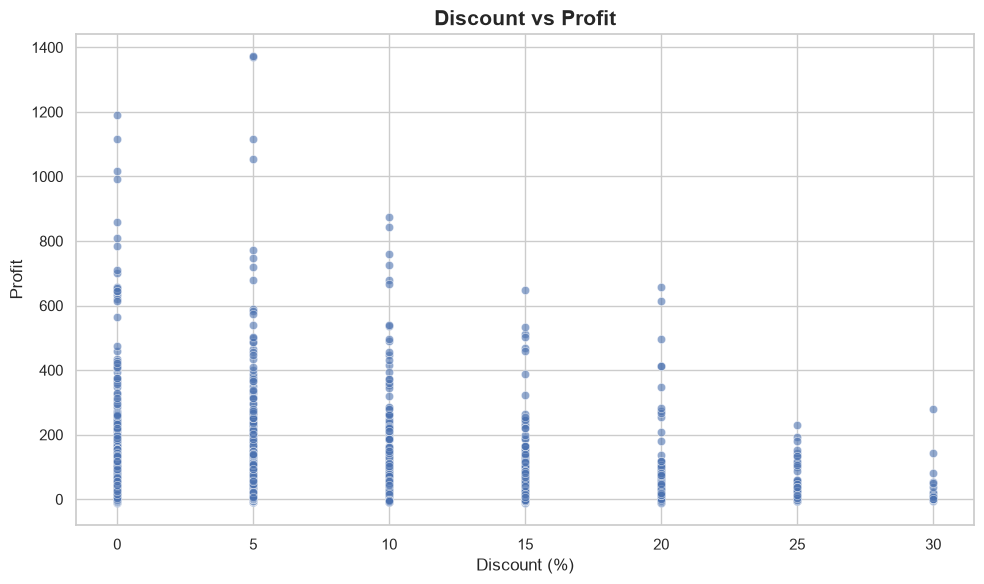

In [570]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Discount_Percent",
    y="Profit",
    alpha=0.6
)

plt.title("Discount vs Profit", fontsize=15, fontweight="bold")
plt.xlabel("Discount (%)")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

# Business Findings

### Key Observations

- Orders with lower discounts (0–5%) generally generate higher profits.
- As the discount percentage increases, profit tends to decline.
- Higher discount levels (25–30%) are mostly associated with lower-profit transactions.
- Although a few exceptions exist, the overall trend indicates a negative relationship between discount and profit.

### Business Interpretation

Offering excessive discounts may increase sales volume, but it can significantly reduce profit margins. A balanced discount strategy is essential to maintain long-term profitability.

### Recommendation

Use targeted discounts instead of blanket promotions. Analyze customer segments and product categories before offering higher discounts to maximize both sales and profit.

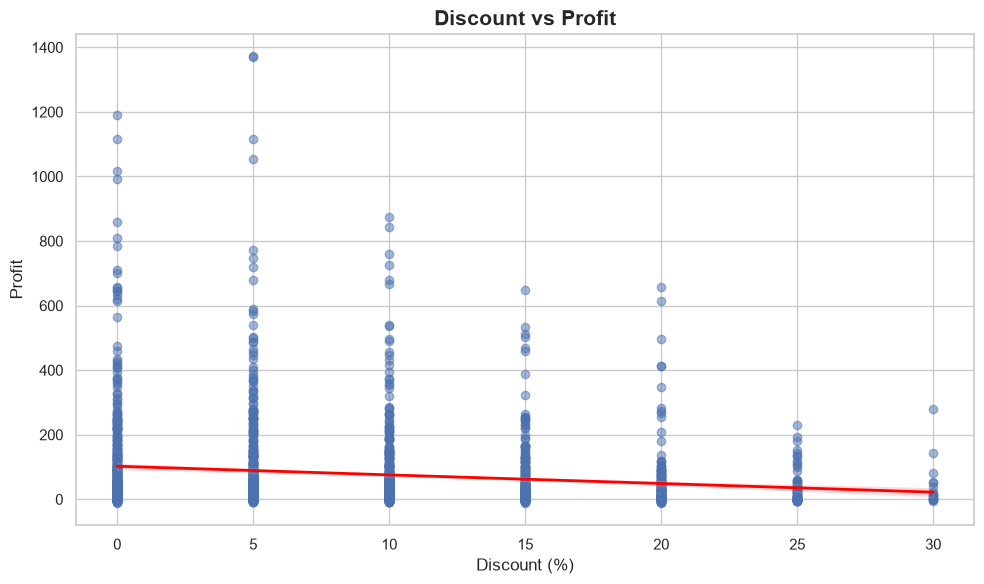

In [571]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="Discount_Percent",
    y="Profit",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red", "linewidth":2}
)

plt.title("Discount vs Profit", fontsize=15, fontweight="bold")
plt.xlabel("Discount (%)")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

# Bivariate Analysis 2 — Quantity vs Total Sales

## Business Question

Does selling a higher quantity of products lead to increased sales revenue?

Understanding the relationship between quantity sold and total sales helps evaluate purchasing behavior, demand patterns, and revenue generation. This insight supports inventory planning and sales strategy.

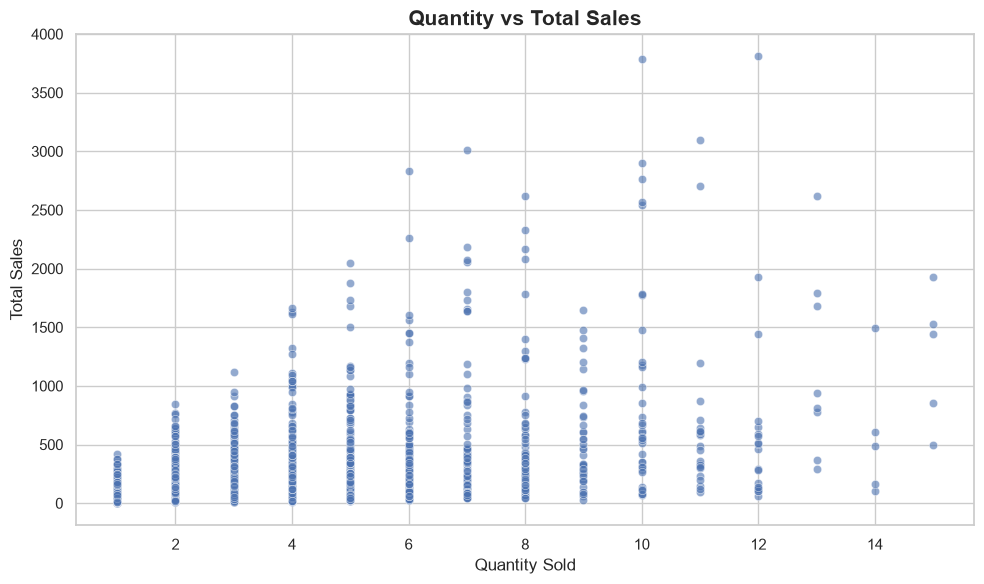

In [572]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Total_Sales",
    alpha=0.6
)

plt.title("Quantity vs Total Sales", fontsize=15, fontweight="bold")
plt.xlabel("Quantity Sold")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [573]:
correlation = df["Quantity"].corr(df["Total_Sales"])

print(f"Correlation between Quantity and Total Sales: {correlation:.3f}")

Correlation between Quantity and Total Sales: 0.503


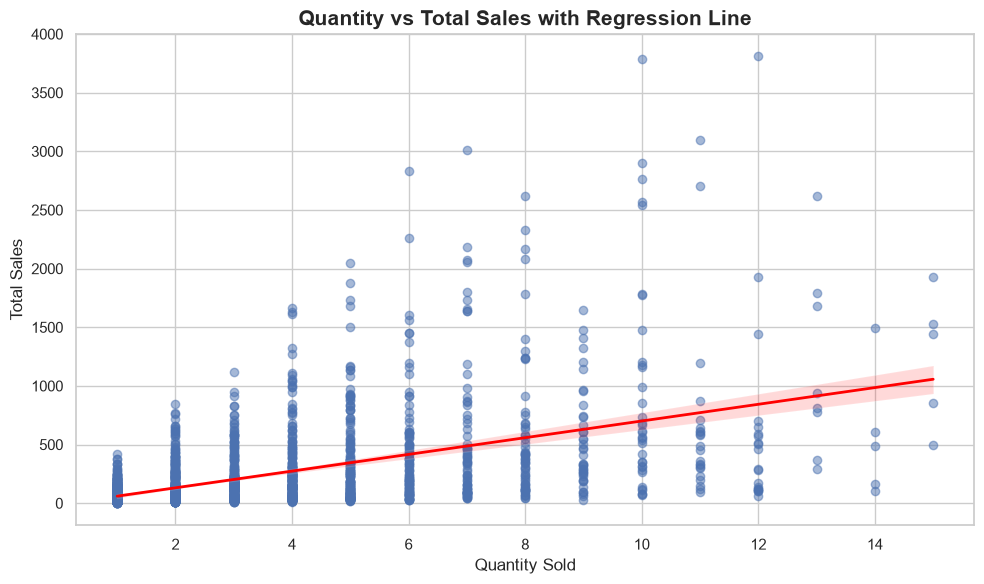

In [574]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="Quantity",
    y="Total_Sales",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red", "linewidth":2}
)

plt.title("Quantity vs Total Sales with Regression Line", fontsize=15, fontweight="bold")
plt.xlabel("Quantity Sold")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [575]:
quantity_summary = (
    df.groupby("Quantity", as_index=False)
      .agg(
          Average_Sales=("Total_Sales", "mean"),
          Orders=("Order_ID", "count")
      )
)

quantity_summary

,Quantity,Average_Sales,Orders
0,1,66.42,495
1,2,135.18,421
2,3,185.15,295
3,4,258.05,248
4,5,344.19,171
5,6,429.12,101
6,7,534.66,73
7,8,557.76,61
8,9,537.02,40
9,10,952.82,35


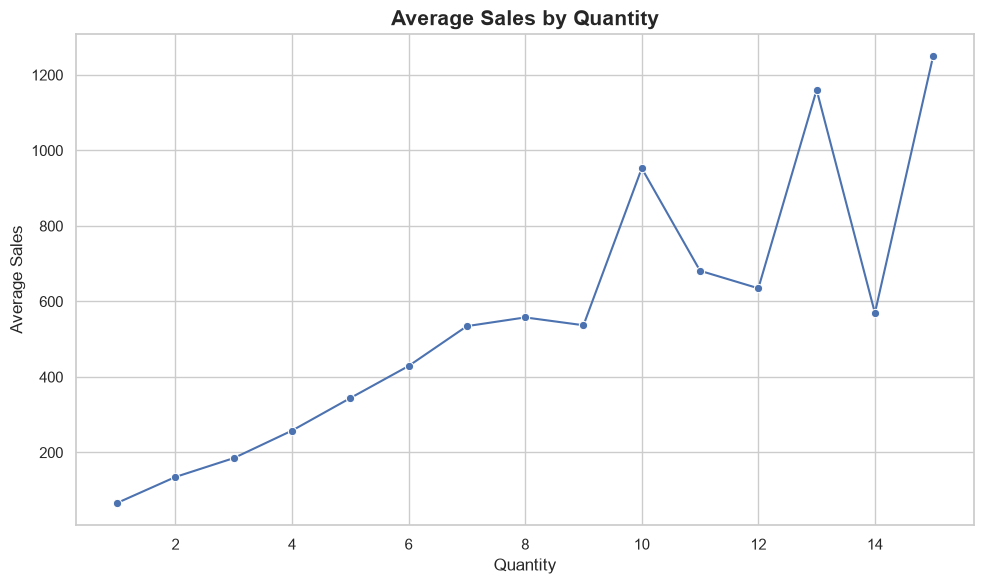

In [576]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=quantity_summary,
    x="Quantity",
    y="Average_Sales",
    marker="o"
)

plt.title("Average Sales by Quantity", fontsize=15, fontweight="bold")
plt.xlabel("Quantity")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

# Business Findings

### Key Observations

- Evaluate whether larger order quantities generate higher sales.
- Observe the strength and direction of the relationship between quantity and revenue.
- Identify any unusual purchasing patterns or outliers.

### Business Interpretation

A positive relationship between quantity and sales indicates that larger purchases contribute significantly to overall revenue. This insight helps identify opportunities for bulk purchase incentives and inventory optimization.

### Recommendation

Introduce volume-based promotions, bundle offers, and bulk purchase discounts where appropriate to encourage higher order quantities while maintaining healthy profit margins.

# Bivariate Analysis 3 — Total Sales vs Profit

## Business Question

Does higher sales revenue always lead to higher profit?

Generating high sales does not necessarily guarantee high profitability. This analysis examines the relationship between revenue and profit to understand whether increased sales contribute to sustainable business growth.

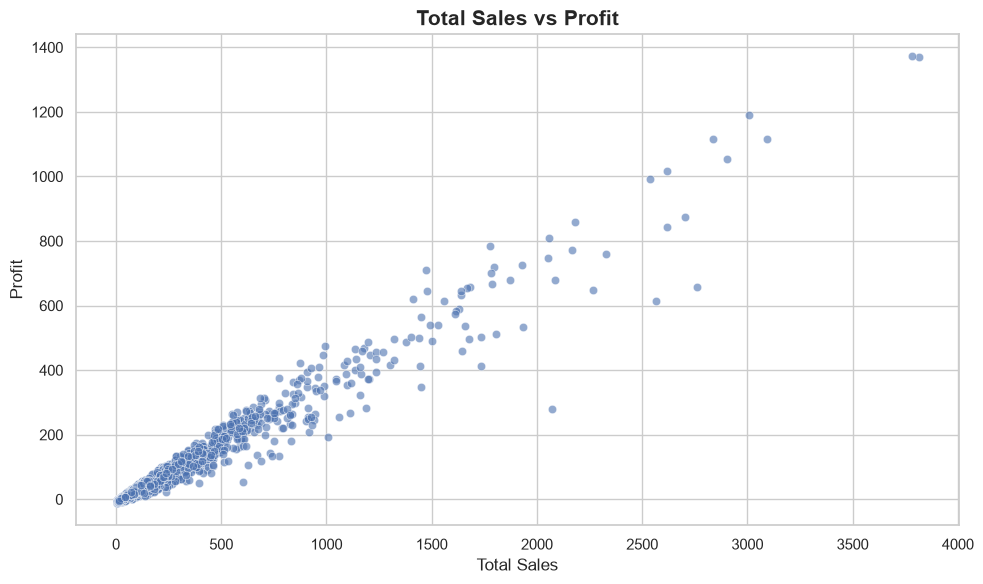

In [577]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Total_Sales",
    y="Profit",
    alpha=0.6
)

plt.title("Total Sales vs Profit", fontsize=15, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [578]:
sales_profit_corr = df["Total_Sales"].corr(df["Profit"])

print(f"Correlation between Total Sales and Profit: {sales_profit_corr:.3f}")

Correlation between Total Sales and Profit: 0.979


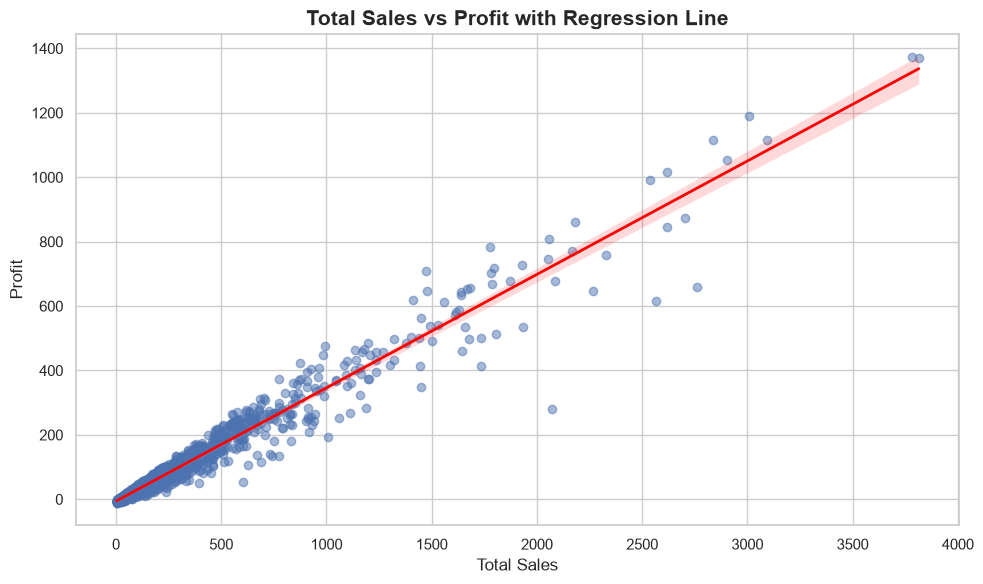

In [579]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="Total_Sales",
    y="Profit",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red", "linewidth":2}
)

plt.title("Total Sales vs Profit with Regression Line",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Total Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [580]:
sales_summary = (
    df.groupby(pd.cut(df["Total_Sales"], bins=6))
      .agg(
          Average_Profit=("Profit", "mean"),
          Orders=("Order_ID", "count")
      )
      .reset_index()
)

sales_summary

,Total_Sales,Average_Profit,Orders
0,"(-1.392, 637.68]",46.67,1827
1,"(637.68, 1272.94]",303.01,117
2,"(1272.94, 1908.2]",562.51,34
3,"(1908.2, 2543.46]",709.70,11
4,"(2543.46, 3178.72]",942.77,9
5,"(3178.72, 3813.98]",1371.86,2


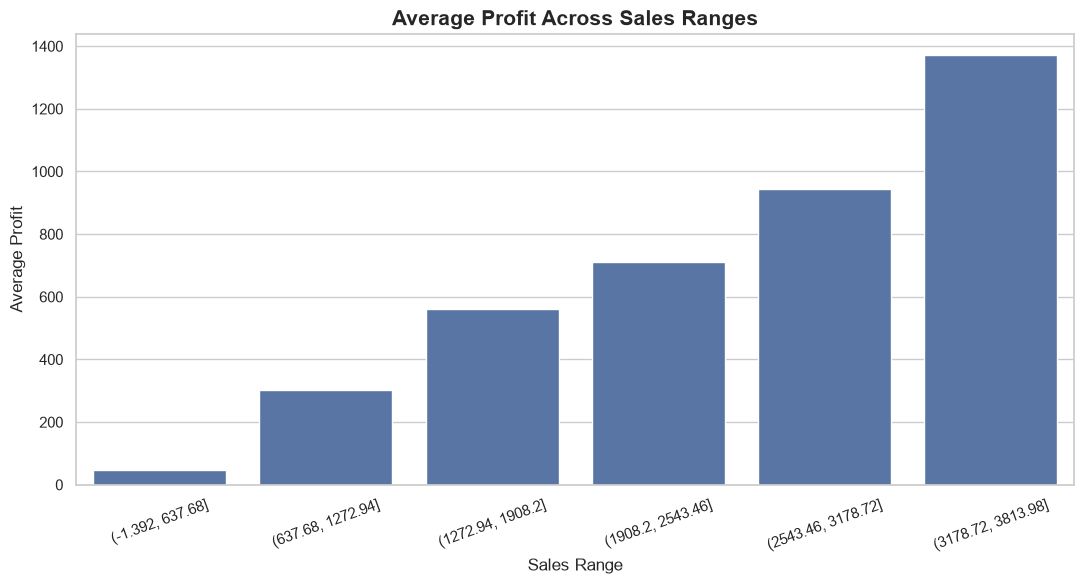

In [581]:
plt.figure(figsize=(11,6))

sns.barplot(
    data=sales_summary,
    x="Total_Sales",
    y="Average_Profit"
)

plt.xticks(rotation=20)

plt.title("Average Profit Across Sales Ranges",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Sales Range")
plt.ylabel("Average Profit")

plt.tight_layout()
plt.show()

# Business Findings

### Key Observations

- Evaluate whether higher sales are associated with higher profits.
- Identify whether profit increases consistently with revenue.
- Observe any sales ranges where profitability is relatively lower.

### Business Interpretation

A strong positive relationship suggests that increasing revenue contributes to higher profitability. However, if profit does not increase proportionally with sales, pricing strategies, discounts, or operational costs may require further analysis.

### Recommendation

Focus on profitable revenue growth rather than increasing sales alone. Monitor both revenue and profit KPIs to ensure sustainable business performance.

# Correlation Analysis

## Business Question

Which numerical variables have the strongest relationships with each other?

Correlation analysis helps identify relationships between key business metrics such as sales, profit, quantity, discounts, unit price, and shipping cost. Understanding these relationships supports better business decision-making and predictive analytics.

In [582]:
numerical_columns = [
    "Quantity",
    "Unit_Price",
    "Discount_Percent",
    "Total_Sales",
    "Shipping_Cost",
    "Profit"
]

correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit
Quantity,1.00,0.02,0.01,0.50,0.77,0.50
Unit_Price,0.02,1.00,0.02,0.70,0.02,0.67
Discount_Percent,0.01,0.02,1.00,-0.05,0.02,-0.14
Total_Sales,0.50,0.70,-0.05,1.00,0.39,0.98
Shipping_Cost,0.77,0.02,0.02,0.39,1.00,0.36
Profit,0.50,0.67,-0.14,0.98,0.36,1.00


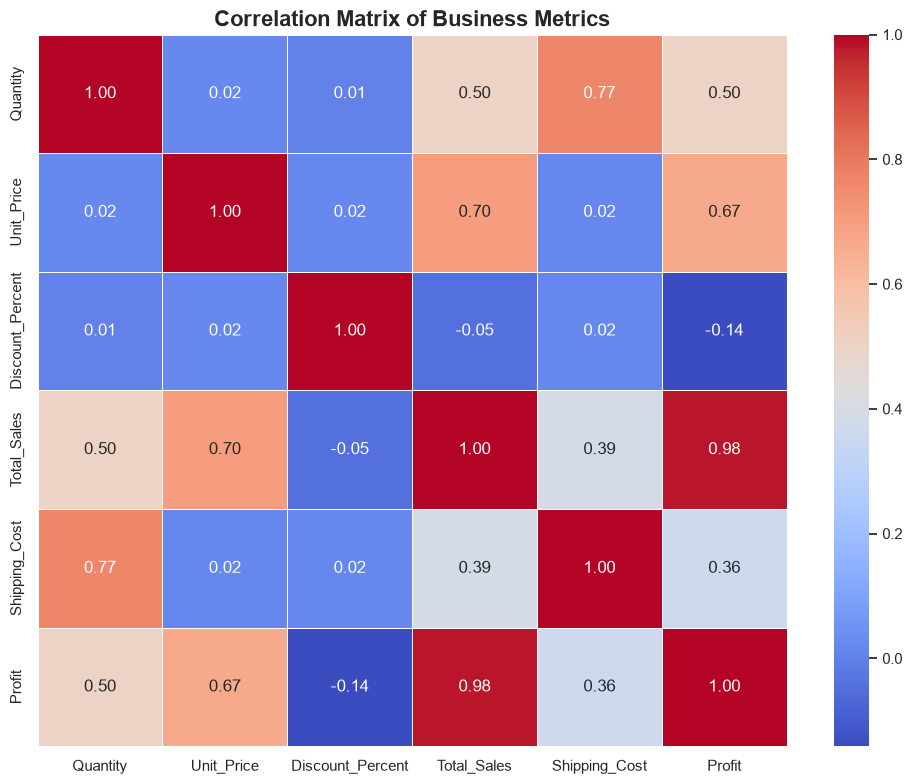

In [583]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Business Metrics",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [584]:
correlation_matrix.style.background_gradient(cmap="coolwarm")

,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit
Quantity,1.000000,0.020364,0.005010,0.503233,0.766924,0.503155
Unit_Price,0.020364,1.000000,0.021263,0.701605,0.017095,0.666903
Discount_Percent,0.005010,0.021263,1.000000,-0.045900,0.015693,-0.141340
Total_Sales,0.503233,0.701605,-0.045900,1.000000,0.385902,0.979217
Shipping_Cost,0.766924,0.017095,0.015693,0.385902,1.000000,0.363832
Profit,0.503155,0.666903,-0.141340,0.979217,0.363832,1.000000


# Business Findings

### Key Observations

- Identify the strongest positive correlations among business metrics.
- Identify any negative correlations that may impact profitability.
- Evaluate how Total Sales, Profit, Quantity, Discount, and Shipping Cost interact.

### Business Interpretation

Strong positive correlations indicate variables that increase together, while negative correlations reveal trade-offs that may affect business performance. These insights support pricing strategy, inventory planning, and profitability optimization.

### Recommendation

Monitor highly correlated KPIs regularly and use these relationships to improve forecasting, pricing decisions, and operational planning.

In [585]:
correlation_pairs = (
    correlation_matrix
    .unstack()
    .sort_values(ascending=False)
)

# Remove duplicate pairs and self-correlations
correlation_pairs = correlation_pairs[
    correlation_pairs.index.get_level_values(0)
    < correlation_pairs.index.get_level_values(1)
]

correlation_pairs

Profit            Total_Sales      0.98
Quantity          Shipping_Cost    0.77
Total_Sales       Unit_Price       0.70
Profit            Unit_Price       0.67
Quantity          Total_Sales      0.50
Profit            Quantity         0.50
Shipping_Cost     Total_Sales      0.39
Profit            Shipping_Cost    0.36
Discount_Percent  Unit_Price       0.02
Quantity          Unit_Price       0.02
Shipping_Cost     Unit_Price       0.02
Discount_Percent  Shipping_Cost    0.02
                  Quantity         0.01
                  Total_Sales     -0.05
                  Profit          -0.14
dtype: float64

# Outlier Detection

## Business Question

Are there unusual observations that may significantly influence business performance?

Outlier detection helps identify exceptionally high or low values in business metrics such as sales, profit, shipping cost, and unit price. These observations may represent premium transactions, operational issues, or potential data quality concerns.

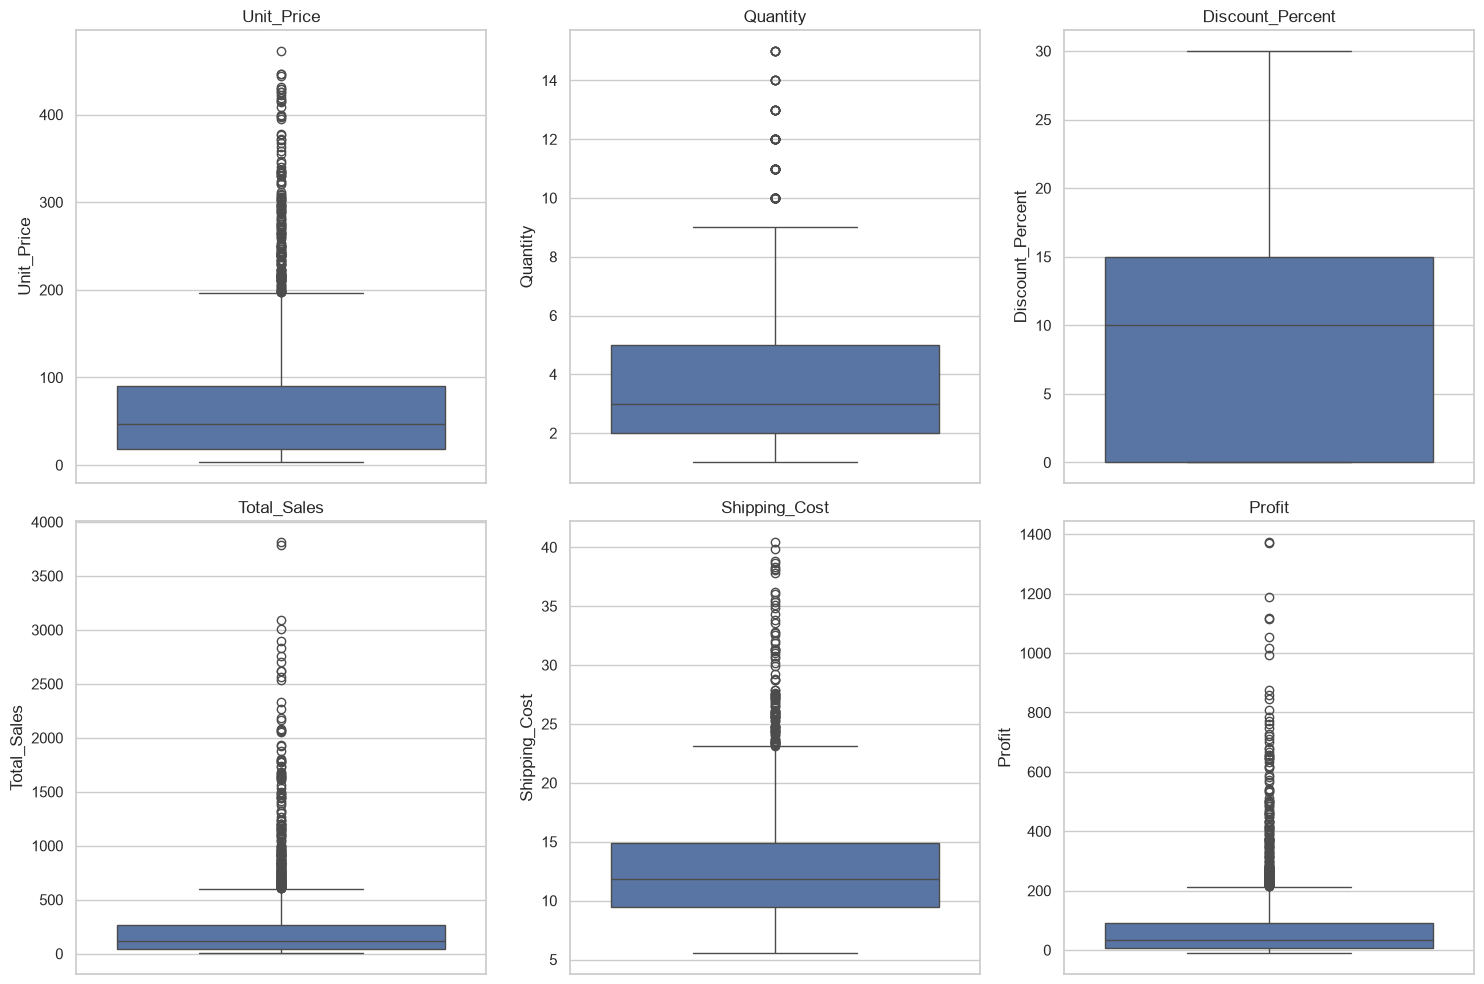

In [586]:
numerical_columns = [
    "Unit_Price",
    "Quantity",
    "Discount_Percent",
    "Total_Sales",
    "Shipping_Cost",
    "Profit"
]

plt.figure(figsize=(15,10))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

In [587]:
outlier_summary = []

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Outliers": count
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,Feature,Outliers
0,Unit_Price,166
1,Quantity,95
2,Discount_Percent,0
3,Total_Sales,190
4,Shipping_Cost,98
5,Profit,204


# Business Findings

### Key Observations

- Identify variables containing unusually high or low observations.
- Evaluate whether these outliers represent genuine business events or potential data quality issues.

### Business Interpretation

Outliers may indicate premium orders, bulk purchases, seasonal demand spikes, or exceptional customer behavior. Rather than removing them automatically, each case should be evaluated based on business context.

### Recommendation

Retain genuine business outliers for analytical purposes while investigating abnormal values that may indicate operational or data-entry errors.

# Executive Business Insights

## Key Insights

1. Product categories contribute differently to revenue and profitability.
2. Higher discounts generally reduce profit margins.
3. Larger order quantities are associated with increased sales.
4. Total Sales and Profit show a strong positive relationship.
5. Regional performance varies, indicating opportunities for targeted expansion.
6. Customer segments differ in revenue contribution and purchasing behavior.
7. Payment method preferences can support customer experience optimization.
8. Correlation analysis highlights key business drivers for future forecasting.

# Business Recommendations

1. Focus marketing investment on high-profit product categories.
2. Implement data-driven discount strategies to protect profitability.
3. Encourage larger order quantities through bundle offers and volume discounts.
4. Strengthen operations in high-performing regions while improving weaker markets.
5. Develop loyalty programs for high-value customer segments.
6. Optimize shipping costs without affecting customer satisfaction.
7. Use predictive analytics to forecast sales and profitability.
8. Continuously monitor KPIs using interactive business dashboards.

# Conclusion

This Exploratory Data Analysis examined key business drivers influencing sales, profitability, customer behavior, regional performance, pricing strategies, and operational efficiency.

The analysis demonstrates that revenue growth alone is not sufficient; profitability, discount management, customer segmentation, and regional performance must all be considered when making strategic business decisions.

The insights generated from this analysis provide a strong foundation for advanced analytics, predictive modeling, and executive dashboard development using Machine Learning and Power BI.